In [1]:
from svd_utils import *
from sklearn.cluster import KMeans
import sys
sys.path.append("../")  # Goes up to "project/"
import numpy as np
import matplotlib.pyplot as plt

TODO

* Use the K-means labels to remove some components from the test vectors.
* Write the test vectors to disk and use them with my DD$\alpha$AMG.
* Compare the iteration count for the original smoothed vectors and the clustered ones.

In [26]:
#Restrict test vectors to a particular block and apply SVD
Nx, Nt, block_x, block_t = 64,64,4,4
x_elements, t_elements = Nx//block_x,Nt//block_t
blockID = 0
bx = blockID // block_x
bt = blockID % block_t 
#----Coordinates of elements inside block----#
xini, tini = x_elements * bx, t_elements * bt
xfin = xini + x_elements
tfin = tini + t_elements
print("Restricting to block {0}".format(blockID))
print("t in range {0} - {1}".format(tini,tfin))
print("x in range {0} - {1}".format(xini,xfin))
print("------------------------")

#[2, "m-018", "-01884",0.008], [4, "m-01023","-01023",0.001], [6, "m-0709","-00709",0.001] [beta, m0_folder, m0_str]
beta, m0_folder ,m0_str, m0_diff = 4, "m-01023","-01023",0.001
nconf = 0
NV = 30
k_rank = 12
SAP_block_size = 16

Restricting to block 0
t in range 0 - 16
x in range 0 - 16
------------------------


# SVD 1
* Restrict test vectors to a lattice block and apply SVD

We restrict the test vectors to a lattice block (we ignore the rest of the components by creating a new vector which only has the components inside the block) and apply the SVD those restricted vectors, for a certain spin.

In [27]:
params_list = [beta, m0_str, m0_folder, nconf, NV, Nx, Nt]
dtv_spin0, dtv_spin1 = read_and_decompose(blockID,block_x,block_t,params_list)
print("\nSpin component 0")
low_rank_tv0 = apply_SVD(dtv_spin0,k_rank)
low_rank_tv0 = low_rank_tv0.reshape(t_elements,x_elements,NV);
print("Low rank test vectors shape after reshaping",low_rank_tv0.shape)
print("\nSpin component 1")
low_rank_tv1 = apply_SVD(dtv_spin1,k_rank)
low_rank_tv1 =low_rank_tv1.reshape(t_elements,x_elements,NV);
print("Low rank test vectors shape after reshaping",low_rank_tv1.shape)

beta=4, conf=0, Nv=30, Nx=64, Nt=64
blocks_x=4, blocks_t=4, bx_size=16, bt_size=16
Test vectors matrix shape (256, 30)

Spin component 0
matrix succesfully reconstructed
-------------------
Uk shape (256, 12)
sk shape (12,)
Vk shape (12, 30)
Low rank test vectors shape (256, 30)
Low rank test vectors shape after reshaping (16, 16, 30)

Spin component 1
matrix succesfully reconstructed
-------------------
Uk shape (256, 12)
sk shape (12,)
Vk shape (12, 30)
Low rank test vectors shape (256, 30)
Low rank test vectors shape after reshaping (16, 16, 30)


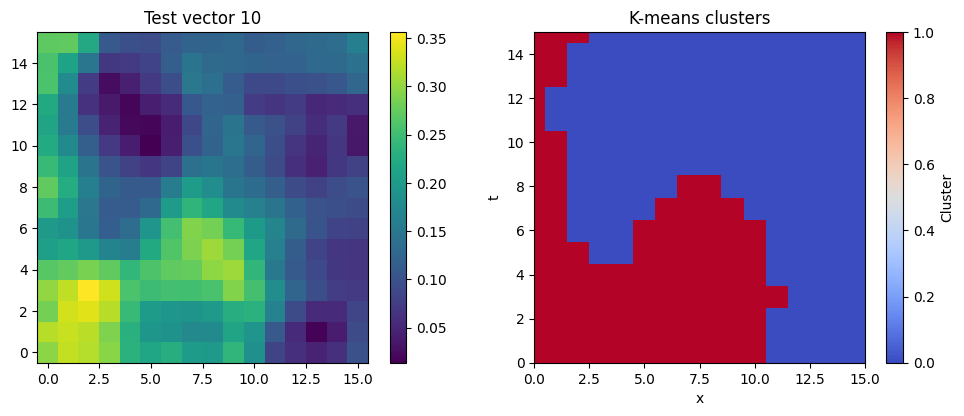

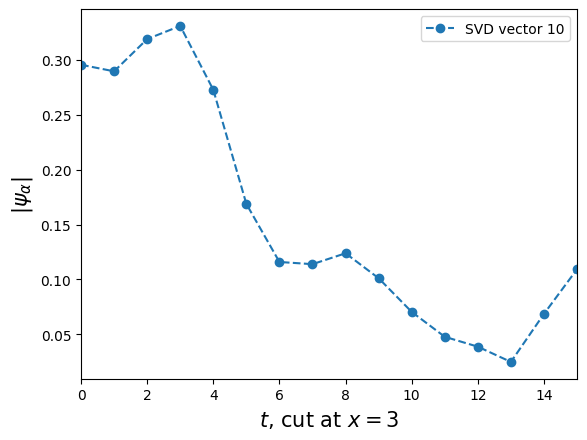

In [28]:
tvID = 10
xlims = [0,x_elements-1]
tlims = [0,t_elements-1]
make_heatmap_and_k_cluster(low_rank_tv1,xlims,tlims,tvID)
#Plot of a cut
cut = 3
X = np.arange(0,low_rank_tv1.shape[0])
plt.plot(X,np.abs(low_rank_tv1[:,cut,tvID]),marker='o',linestyle='--',label='SVD vector {0}'.format(tvID))
plt.legend()
plt.ylabel(r"$|\psi_\alpha|$",size=15)
plt.xlabel(r"$t$, cut at $x=${0}".format(cut),size=15)
plt.xlim(tlims)
plt.show()

In [ ]:
fig_name = "heatmaps_blockID{0}_bsize{1}_beta{2}.pdf".format(blockID,x_elements,beta)
metadata = [Nx, Nt, beta, m0_diff, x_elements,blockID, k_rank, NV,SAP_block_size]
make_heatmaps(low_rank_tv0, low_rank_tv1,xlims,tlims,metadata,fig_name,save=True)

# SVD 2
* Restrict test vectors and apply SVD, but this time we keep the original dimensions of the vectors and only zero-out those components outside of the domain.

This is equivalent to SVD 1, I just wanted to verify.

In [ ]:
params_list = [beta, m0_str, m0_folder, nconf, NV, Nx, Nt]
dtv_spin0, dtv_spin1 = read_and_decompose_v2(blockID,block_x,block_t,params_list)
print("\nSpin component 0")
low_rank_tv0 = apply_SVD(dtv_spin0,k_rank)
low_rank_tv0 = low_rank_tv0.reshape(Nt,Nx,NV);
print("Low rank test vectors shape after reshaping",low_rank_tv0.shape)
print("\nSpin component 1")
low_rank_tv1 = apply_SVD(dtv_spin1,k_rank)
low_rank_tv1 =low_rank_tv1.reshape(Nt,Nx,NV);
print("Low rank test vectors shape after reshaping",low_rank_tv1.shape)

In [ ]:
tvID = 0
xlims = [xini,xfin-1]
tlims = [tini,tfin-1]
make_heatmap(low_rank_tv1,xlims,tlims,tvID)
#Plot of a cut
cut = xini
X = np.arange(0,low_rank_tv1.shape[0])
plt.plot(X,np.abs(low_rank_tv1[:,cut,tvID]),marker='o',linestyle='--',label='SVD vector {0}'.format(tvID))
plt.legend()
plt.ylabel(r"$|\psi_\alpha|$",size=15)
plt.xlabel(r"$t$, cut at $x=${0}".format(cut),size=15)
plt.xlim(tlims)
plt.show()

In [ ]:
fig_name = "heatmaps_blockID{0}_bsize{1}x{1}_beta{2}_v2.pdf".format(blockID,x_elements,beta)
metadata = [Nx, Nt, beta, m0_diff, x_elements,blockID, k_rank, NV]
make_heatmaps(low_rank_tv0, low_rank_tv1,xlims, tlims,metadata,fig_name,save=False)

In [ ]:
#random_array = np.random.rand(16,16)
#fig, ax = plt.subplots()
#im = ax.imshow(random_array)
#ax.set_xlabel(r"x")
#ax.set_ylabel(r"t")
#ax.figure.colorbar(im, ax=ax)
#fig.tight_layout()
#plt.show()

# Plot test vectors without SVD

In [ ]:
#Open test vectors of a particular gauge configuration and store them in columns
beta, N, m0_str = 2, 64, "-01884"
nconf = 0
tv = 0 
NV = 30
spin = 0 #0 or 1
test_vectors = np.zeros((NV,N*N),dtype=complex)
for tv in range(NV):
    path = "../real_tv/b{0}_{1}x{1}/m-018/tvector_{1}x{1}_b{0}0000_m{2}_nconf{3}_tv{4}.tv".format(
        beta, N, m0_str, nconf, tv
        )
    test_vector = read_binary_conf(N,N,path)
    flatten_vector_spin0 = test_vector[spin].flatten()
    test_vectors[tv] = flatten_vector_spin0
#We plot the test vectors by taking cuts at different x
X = np.arange(0,N,1)
for i in range(1,4):
    cut1 = np.abs(test_vector[spin,:,i])
    plt.plot(X,cut1,marker='o',linestyle='--',label=r'$x=${0}'.format(i))
plt.xlabel(r"$t$",size=15)
plt.ylabel(r"$|\psi_\alpha|$",size=15)
plt.legend()
plt.show()
tvec = np.abs(test_vector[spin].reshape(-1))
#Linearize everything
X = np.arange(0,tvec.shape[0])
plt.plot(X,tvec,marker='o',linestyle='--',label='cut {0}'.format(i))
plt.legend()
plt.xlim([0,58])
plt.show()